In [108]:
# Cell 1: Import Libraries and Set Configuration
"""
Experiment: Chain graph with random prior on X1, uniform priors on X2-X10
Vary random seed and plot KL divergence against seed
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import sys
sys.path.insert(0, '/home/tom/Projects/gbp_clt/src')
import config as cfg
import distribution_management as dm
from factor_graph import FactorGraph
from belief_propagation import run_belief_propagation
import optimisation as opt

# Fixed parameters
cfg.belief_discretisation = 128
cfg.smoothing_width = 8
cfg.prior_width = 8
cfg.num_iterations = 20  # Enough iterations for convergence
cfg.min_measurement = 0
cfg.max_measurement = 63
cfg.measurement_range = np.linspace(cfg.min_measurement, cfg.max_measurement, cfg.belief_discretisation)

# Select a few representative exponent values to visualize
n_samples = np.logspace(-3, 3, num=100)
prior_noise_smoothing_width = 5.0

# Experiment parameters
num_variables = 20
num_seeds = 50 # use 500 for final experiment (clean curves)

In [109]:
# Cell 2: helper functions

def create_uniform_perturbed_by_white_noise(n):    
    white_noise = np.random.rand(cfg.belief_discretisation)
    white_noise = gaussian_filter1d(white_noise, sigma=prior_noise_smoothing_width) #testing smoothing
    
    if n > 100:
        # compute in log space to avoid numerical issues
        log_white_noise = n * np.log(white_noise + 1e-300)  # Add small value to avoid log(0)
        white_noise = np.exp(log_white_noise - np.max(log_white_noise))  # Subtract max for numerical stability
    else:
        white_noise = white_noise**n
    white_noise = dm.normalise(white_noise)
    return white_noise

def calculate_entropy_bit(distribution):
    p = distribution + 1e-12  # Avoid log(0)
    entropy = -np.sum(p * np.log2(p))
    return entropy

def optimise_gaussian_kl_robust(y_values, x_values):
    """Find Gaussian that minimizes KL divergence from target_belief"""
    bin_width = (x_values[-1] - x_values[0]) / len(x_values)
    sigma_min = 2*bin_width
    sigma_max = (x_values[-1] - x_values[0]) * 10.0
    num_sigma_steps = 100
    
    optimal_mean = x_values[np.argmax(y_values)]
    sigma_search_values = np.logspace(np.log10(sigma_min), np.log10(sigma_max), num_sigma_steps)
    min_kl = float('inf')
    optimal_sigma = None
        
    for sigma_candidate in sigma_search_values:
        y_gauss = opt.create_gaussian_distribution(x_values, sigma_candidate, mu=optimal_mean)
        current_kl = opt.kl_divergence_numba(y_values, y_gauss)

        if np.isnan(current_kl):
            continue

        if current_kl < min_kl:
            min_kl = current_kl
            optimal_sigma = sigma_candidate

    return min_kl, optimal_sigma, optimal_mean

def sample_evenly(arr, n):
    # n must be <= len(arr)
    idx = np.linspace(0, len(arr)-1, n, dtype=int)
    return arr[idx], idx

def calculate_std_dev(distribution, x_values):
    mean = np.sum(distribution * x_values)
    variance = np.sum(distribution * (x_values - mean)**2)
    std_dev = np.sqrt(variance)
    return std_dev

In [110]:
# Cell 3: Run Experiment

seeds = np.arange(42, 42+num_seeds)
seed_for_visualisation = 42

all_kl_divergences = []     # Shape: (num_seeds, len(n_samples))
all_final_beliefs_x10 = []  # Shape: (num_seeds, len(n_samples), belief_discretisation)
all_entropy_values = []     # Shape: (num_seeds, len(n_samples))
all_std_dev_values = []     # Shape: (num_seeds, len(n_samples))

print(f"Running chain graph experiment with {num_variables} variables...")
print(f"Testing {num_seeds} different random seeds\n")

for seed in seeds:
    print(f"Running seed {seed}...")

    # Set random seed
    cfg.random_seed = seed
    cfg.rng = np.random.default_rng(seed=seed)
    np.random.seed(seed)

    seed_kl_divergences = []
    seed_final_beliefs_x10 = []
    seed_entropy_values = []
    seed_std_dev_values = []

    for n in n_samples:
        print(f" Testing seed {seed}, n={n}...")

        # Build factor graph - chain structure
        graph = FactorGraph()
        graph.add_variables(num_variables, cfg.belief_discretisation)

        # Add smoothing factors to create chain: X1-X2-X3-...-X10
        kernel_range = np.linspace(-cfg.smoothing_width//2, cfg.smoothing_width//2, cfg.belief_discretisation)
        smoothing_kernel = dm.create_random_prior_distribution(kernel_range, prior_width=cfg.prior_width)
        smoothing_function = dm.create_smoothing_factor_distribution(
            cfg.belief_discretisation, 
            kernel=smoothing_kernel
        )

        for i in range(num_variables - 1):
            graph.add_factor(
                [graph.variables[i], graph.variables[i + 1]], 
                function=smoothing_function
            )

        # Add priors
        # All variables get uniform priors
        # X1 gets random (spiky white noise) prior
        random_prior = dm.create_random_prior_distribution(cfg.measurement_range, prior_width=cfg.prior_width)
        graph.add_factor([graph.variables[0]], random_prior, factor_type='prior')
        
        # X2-X10 get uniform priors
        prior_distribution = create_uniform_perturbed_by_white_noise(n)
        prior_entropy = calculate_entropy_bit(prior_distribution)
        for i in range(1,num_variables):
            graph.add_factor([graph.variables[i]], prior_distribution, factor_type='prior')

        # Run belief propagation
        graph = run_belief_propagation(graph, cfg.num_iterations)

        # Calculate KL divergence for X10 (last variable)
        x10_belief = graph.variables[-1].belief
        min_kl, _, _ = optimise_gaussian_kl_robust(x10_belief, cfg.measurement_range)
        seed_kl_divergences.append(min_kl)
        seed_final_beliefs_x10.append(x10_belief.copy())
        seed_entropy_values.append(prior_entropy)
        seed_std_dev_values.append(calculate_std_dev(prior_distribution, cfg.measurement_range))

        print(f"  X10 KL divergence: {min_kl:.6f}\n")
    
    all_kl_divergences.append(seed_kl_divergences)
    all_final_beliefs_x10.append(seed_final_beliefs_x10)
    all_entropy_values.append(seed_entropy_values)
    all_std_dev_values.append(seed_std_dev_values)

# Convert to numpy arrays for easier indexing
all_kl_divergences = np.array(all_kl_divergences)        # Shape: (num_seeds, len(n_samples))
all_final_beliefs_x10 = np.array(all_final_beliefs_x10)  # Shape: (num_seeds, len(n_samples), belief_discretisation)
all_entropy_values = np.array(all_entropy_values)        # Shape: (num_seeds, len(n_samples))
all_std_dev_values = np.array(all_std_dev_values)        # Shape: (num_seeds, len(n_samples))

# Extract single seed for visualization (cells 4 and 5)
visualization_seed_idx = np.where(seeds == seed_for_visualisation)[0][0]
kl_divergences = all_kl_divergences[visualization_seed_idx]
final_beliefs_x10 = all_final_beliefs_x10[visualization_seed_idx]
entropy_values = all_entropy_values[visualization_seed_idx]  # Use stored entropy values
std_dev_values = all_std_dev_values[visualization_seed_idx] # Use stored std dev values

print(f"Experiment complete!")
print(f"Mean KL divergence across all seeds: {np.mean(all_kl_divergences):.6f}")
print(f"Std KL divergence across all seeds: {np.std(all_kl_divergences):.6f}")

Running chain graph experiment with 20 variables...
Testing 50 different random seeds

Running seed 42...
 Testing seed 42, n=0.001...
Adding variables to graph...
BP Stage 1: Converting graph to numerical representation...
BP Stage 2: Running BP iterations...
BP Stage 3: Updating graph objects with final beliefs...
  X10 KL divergence: 0.000908

 Testing seed 42, n=0.0011497569953977356...
Adding variables to graph...
BP Stage 1: Converting graph to numerical representation...
BP Stage 2: Running BP iterations...
BP Stage 3: Updating graph objects with final beliefs...
  X10 KL divergence: 0.000574

 Testing seed 42, n=0.0013219411484660286...
Adding variables to graph...
BP Stage 1: Converting graph to numerical representation...
BP Stage 2: Running BP iterations...
BP Stage 3: Updating graph objects with final beliefs...
  X10 KL divergence: 0.000957

 Testing seed 42, n=0.0015199110829529332...
Adding variables to graph...
BP Stage 1: Converting graph to numerical representation...

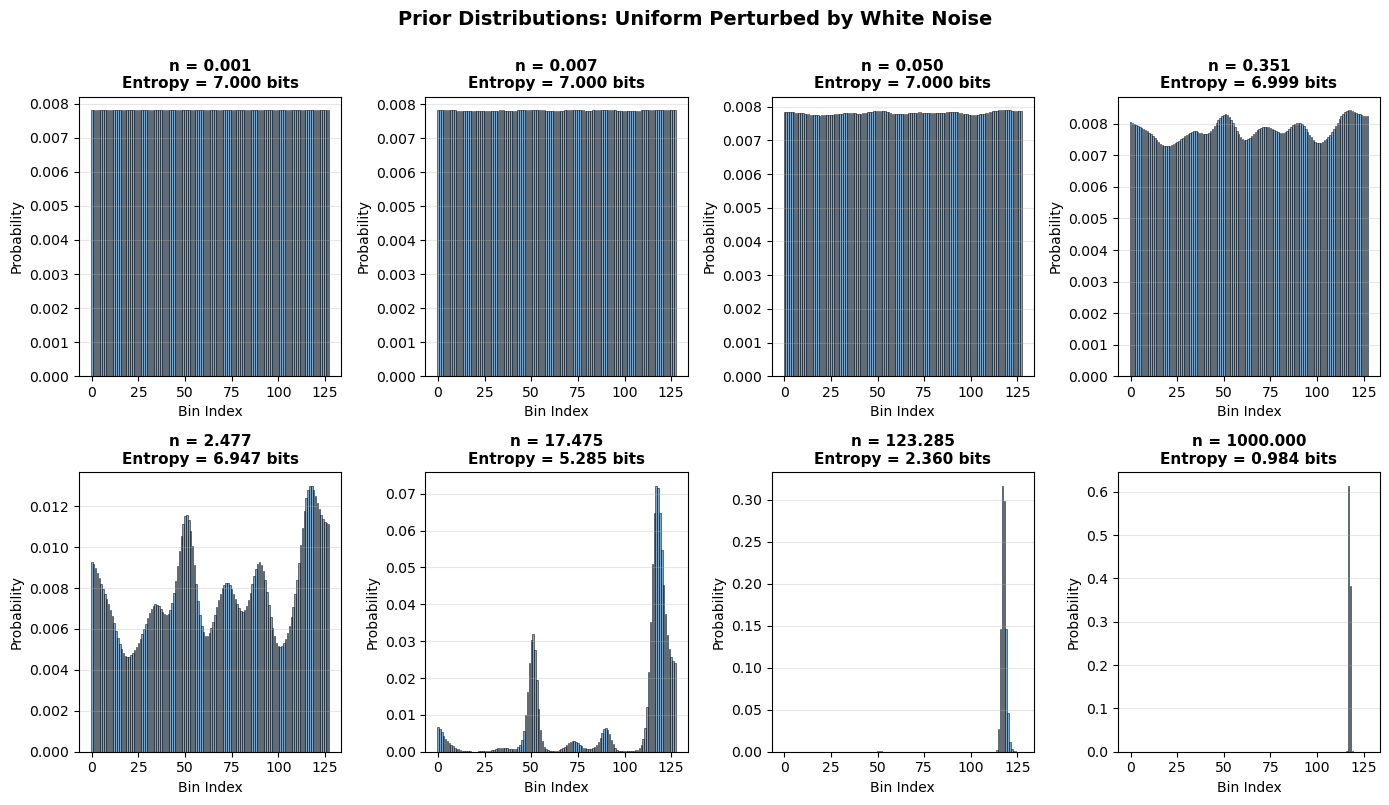

In [111]:
# Cell 4: Visualize Prior Distributions for Different n Values
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()
n_samples_to_plot, idx_to_plot = sample_evenly(n_samples, 8)  # Select first 8 n values for plotting

np.random.seed(seed_for_visualisation)
prior = create_uniform_perturbed_by_white_noise(1)

for idx, n in enumerate(n_samples_to_plot):
    # Create the mixture prior
    if n > 100:
        # compute in log space to avoid numerical issues
        log_test_prior = n * np.log(prior + 1e-300)  # Add small value to avoid log(0)
        test_prior = np.exp(log_test_prior - np.max(log_test_prior))  # Subtract max for numerical stability
    else:
        test_prior = prior**n
    test_prior = dm.normalise(test_prior)
    prior_entropy = calculate_entropy_bit(test_prior)

    # Plot
    axes[idx].bar(range(cfg.belief_discretisation), test_prior, color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.5)
    axes[idx].set_title(f'n = {n:.3f}\nEntropy = {prior_entropy:.3f} bits', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Bin Index', fontsize=10)
    axes[idx].set_ylabel('Probability', fontsize=10)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Prior Distributions: Uniform Perturbed by White Noise', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

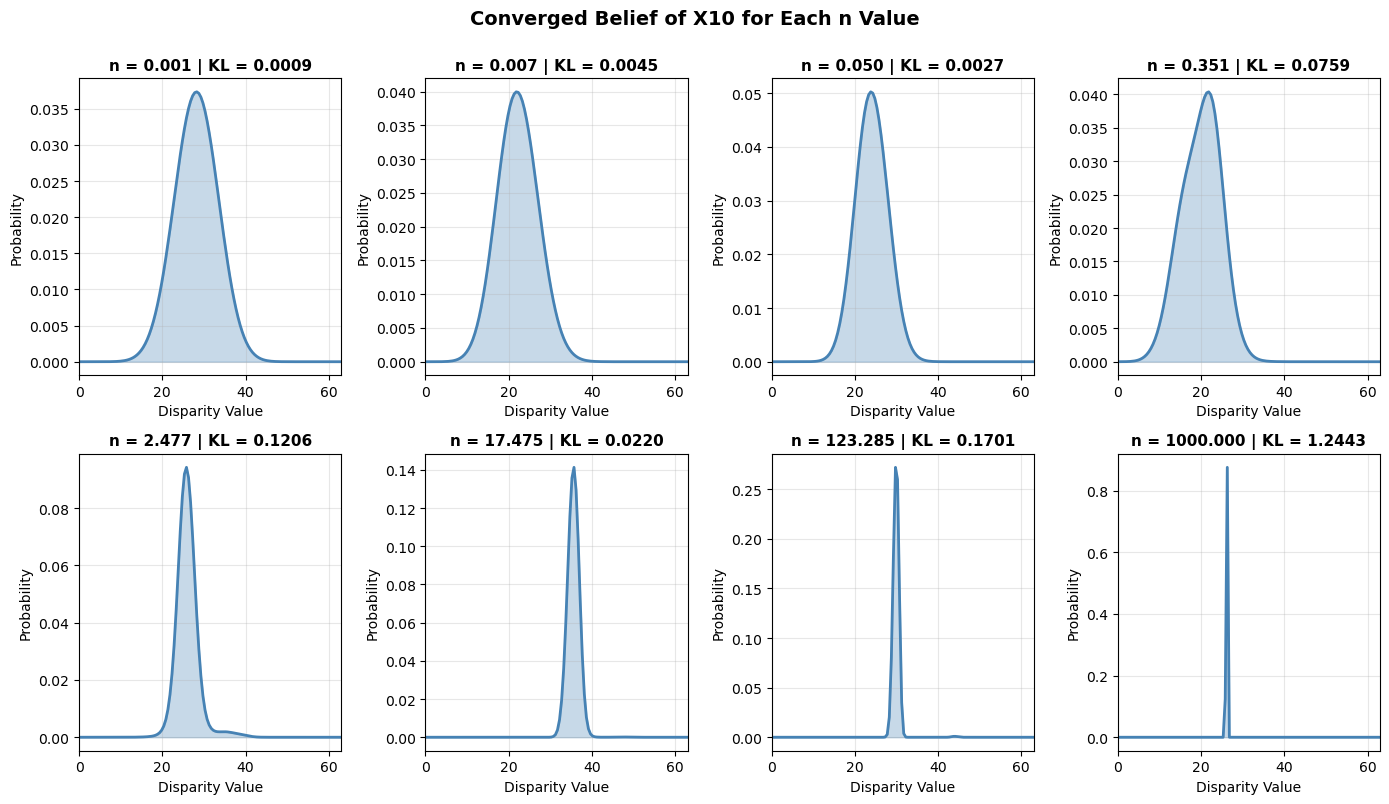

In [112]:
# Cell 5: Visualise Converged Beliefs
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()
final_beliefs_to_plot = np.stack(final_beliefs_x10, axis=0)[idx_to_plot]  # Select first 8 beliefs for plotting

for idx, (n, belief) in enumerate(zip(n_samples_to_plot, final_beliefs_to_plot)):
    # Plot the belief distribution
    axes[idx].plot(cfg.measurement_range, belief, linewidth=2, color='steelblue')
    axes[idx].fill_between(cfg.measurement_range, belief, alpha=0.3, color='steelblue')
    axes[idx].set_title(f'n = {n:.3f} | KL = {kl_divergences[idx_to_plot[idx]]:.4f}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Disparity Value', fontsize=10)
    axes[idx].set_ylabel('Probability', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([cfg.min_measurement, cfg.max_measurement])

plt.suptitle(f'Converged Belief of X10 for Each n Value', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

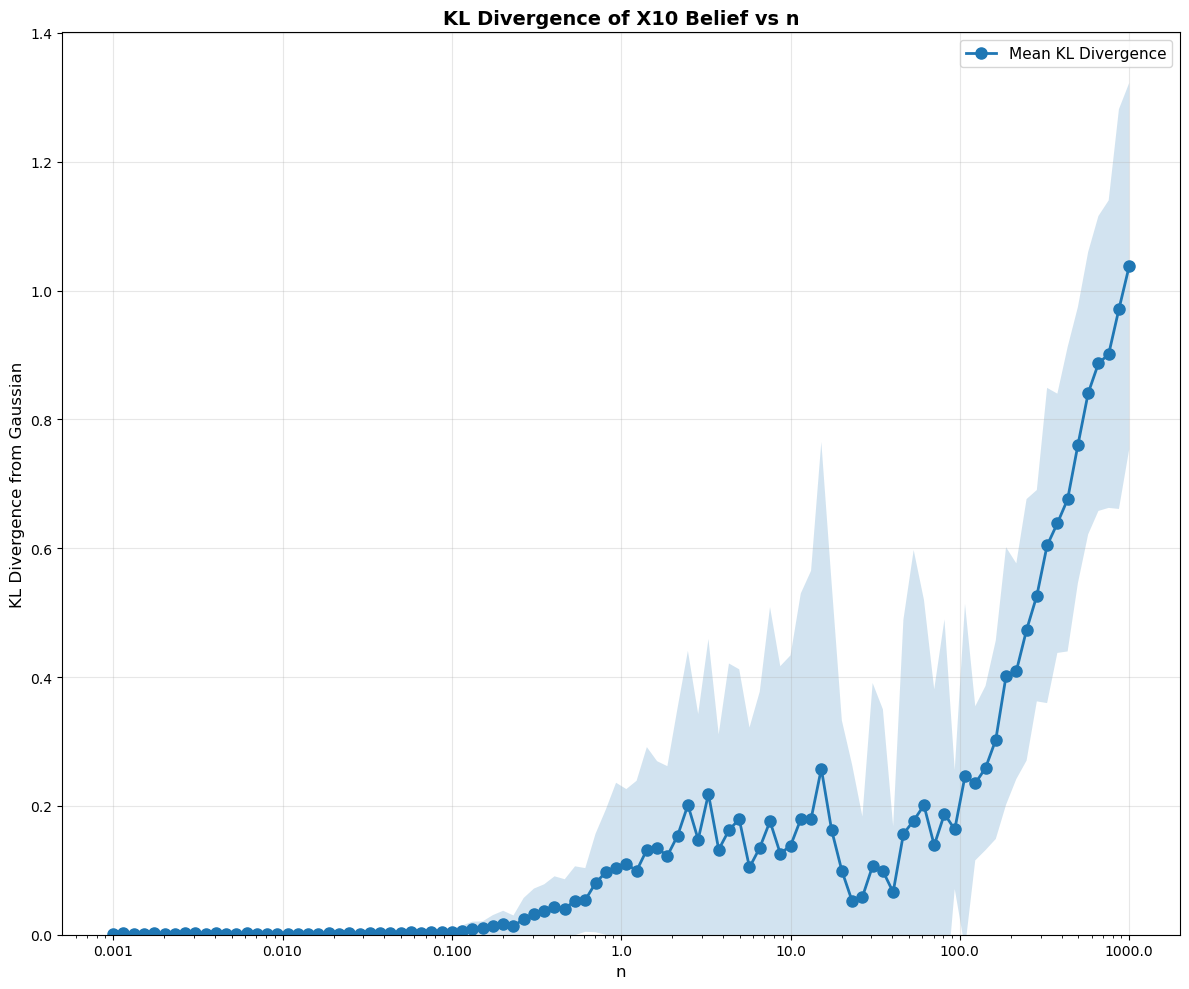

In [113]:
# Cell 6: Plot KL Divergence vs n Values

# Plot 1: KL divergence vs n
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# calculate entropy for each n value
# entropy_values = np.array([calculate_entropy_bit(create_uniform_perturbed_by_white_noise(n)) for n in n_samples])

# Calculate mean and std across seeds
mean_kl = np.mean(all_kl_divergences, axis=0)
std_kl = np.std(all_kl_divergences, axis=0)

# n-values: plot mean with shaded std deviation
ax.plot(n_samples, mean_kl, 'o-', linewidth=2, markersize=8, label='Mean KL Divergence')
ax.fill_between(n_samples, mean_kl - std_kl, mean_kl + std_kl, alpha=0.2)

ax.set_xlabel('n', fontsize=12)
ax.set_ylabel('KL Divergence from Gaussian', fontsize=12)
ax.set_title('KL Divergence of X10 Belief vs n', fontsize=14, fontweight='bold')
ax.set_xscale("log")

ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# n-values: plot formatting
from matplotlib.ticker import LogLocator, NullFormatter, FuncFormatter
min_n = float(np.min(n_samples))
max_n = float(np.max(n_samples))
decades = np.arange(np.floor(np.log10(min_n)), np.ceil(np.log10(max_n)) + 1)

# Major ticks at powers of 10
ax.set_xticks(10**decades)
# Minor ticks between decades (no labels)
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
ax.xaxis.set_minor_formatter(NullFormatter())

# Readable labels: more precision below 1, one decimal above
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:.3f}' if x < 1 else f'{x:.1f}'))

plt.tight_layout()
plt.show()

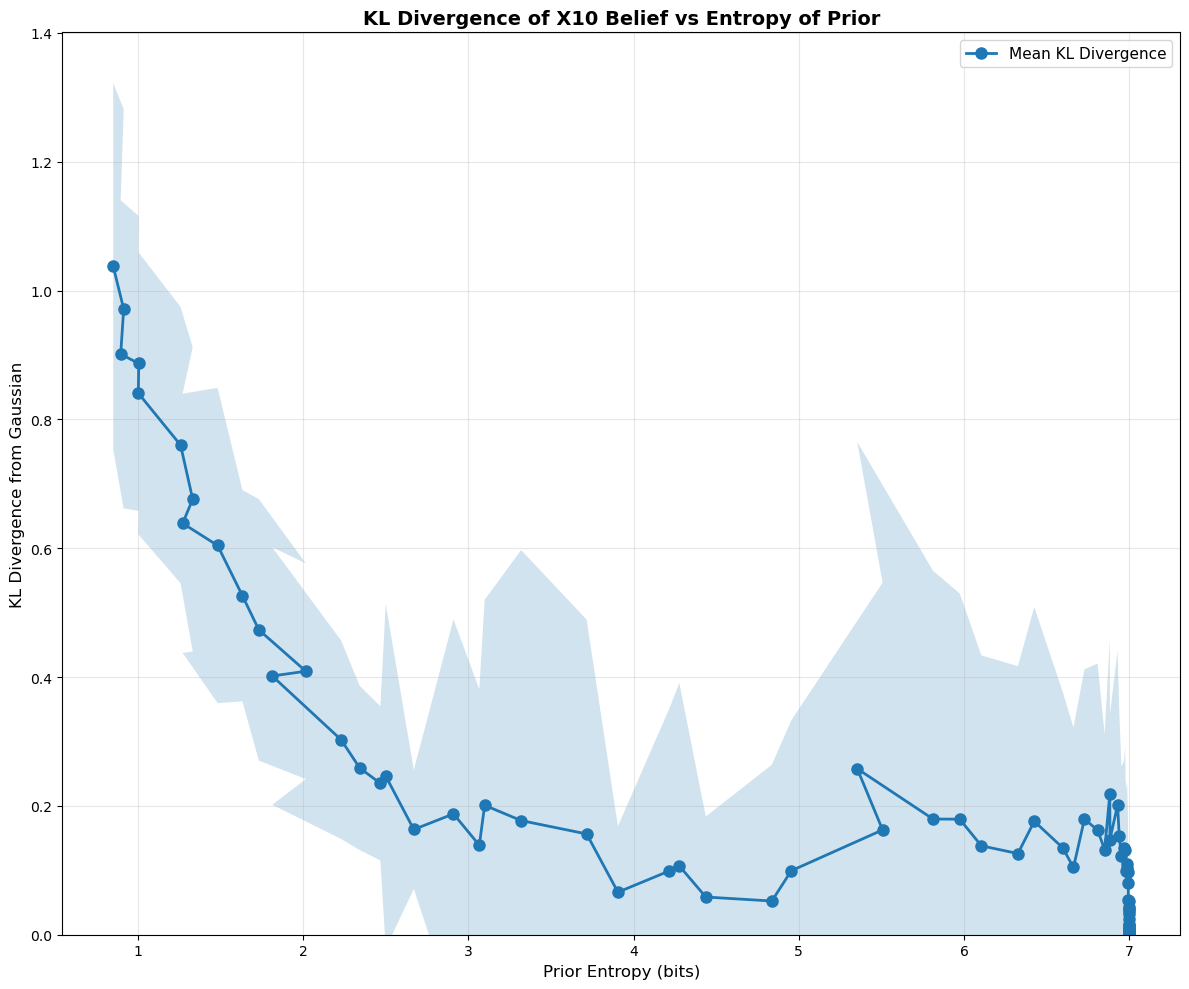

In [114]:
# Cell 7: Plot KL Divergence vs Prior Entropy

# Plot 1: KL divergence vs n
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Calculate mean and std across seeds
mean_kl = np.mean(all_kl_divergences, axis=0)
std_kl = np.std(all_kl_divergences, axis=0)
mean_entropy = np.mean(all_entropy_values, axis=0)

# entropy: plot mean with shaded std deviation
ax.plot(mean_entropy, mean_kl, 'o-', linewidth=2, markersize=8, label='Mean KL Divergence')
ax.fill_between(mean_entropy, mean_kl - std_kl, mean_kl + std_kl, alpha=0.2)

ax.set_xlabel('Prior Entropy (bits)', fontsize=12)
ax.set_ylabel('KL Divergence from Gaussian', fontsize=12)
ax.set_title(f'KL Divergence of X10 Belief vs Entropy of Prior', fontsize=14, fontweight='bold')

ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

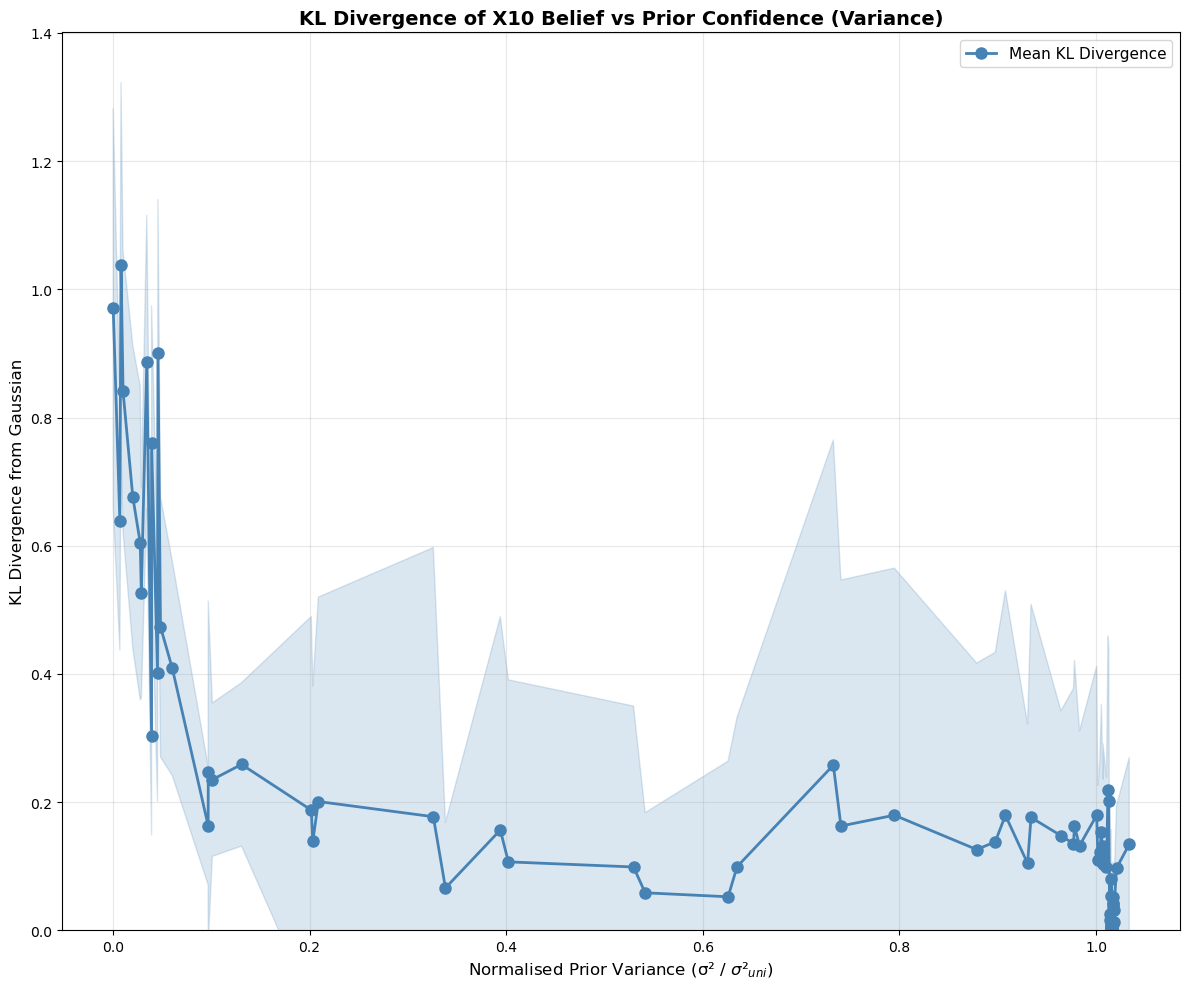

In [120]:
# Cell 8: Plot KL Divergence against Standard Deviation

# Use stored standard deviation values & normalise by uniform distribution
mean_std_dev = np.mean(np.square(all_std_dev_values), axis=0)
uniform_std = (cfg.max_measurement - cfg.min_measurement)**2 / 12
normalised_std_dev = mean_std_dev / uniform_std

# Calculate mean and std across seeds
mean_kl = np.mean(all_kl_divergences, axis=0)
std_kl = np.std(all_kl_divergences, axis=0)

# Sort by standard deviation to prevent zigzagging
sort_idx = np.argsort(normalised_std_dev)
normalised_std_dev = normalised_std_dev[sort_idx]
mean_kl = mean_kl[sort_idx]
std_kl = std_kl[sort_idx]

# Plot KL divergence vs Standard Deviation
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot mean with shaded std deviation
ax.plot(normalised_std_dev, mean_kl, 'o-', linewidth=2, markersize=8, label='Mean KL Divergence', color='steelblue')
ax.fill_between(normalised_std_dev, mean_kl - std_kl, mean_kl + std_kl, alpha=0.2, color='steelblue')

ax.set_xlabel('Normalised Prior Variance (σ² / $σ²_{uni}$)', fontsize=12)
ax.set_ylabel('KL Divergence from Gaussian', fontsize=12)
ax.set_title('KL Divergence of X10 Belief vs Prior Confidence (Variance)', fontsize=14, fontweight='bold')

ax.set_ylim(bottom=0)
# ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()


# # testing
# # Cell 8: Plot KL Divergence against Standard Deviation

# # Use stored standard deviation values & normalise by uniform distribution
# mean_std_dev = np.mean(all_std_dev_values, axis=0)
# uniform_std = (cfg.max_measurement - cfg.min_measurement) / np.sqrt(12)
# normalised_std_dev = mean_std_dev / uniform_std
# mean_kl = np.mean(all_kl_divergences, axis=0)
# std_kl = np.std(all_kl_divergences, axis=0)

# # Sort by standard deviation
# sort_idx = np.argsort(normalised_std_dev)
# normalised_std_dev_sorted = normalised_std_dev[sort_idx]
# mean_kl_sorted = mean_kl[sort_idx]
# std_kl_sorted = std_kl[sort_idx]

# # Bin the data for smoother visualization
# num_bins = 20
# bin_edges = np.linspace(normalised_std_dev_sorted.min(), normalised_std_dev_sorted.max(), num_bins + 1)
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# binned_kl = []
# binned_std = []

# for i in range(num_bins):
#     mask = (normalised_std_dev_sorted >= bin_edges[i]) & (normalised_std_dev_sorted < bin_edges[i+1])
#     if np.any(mask):
#         binned_kl.append(np.mean(mean_kl_sorted[mask]))
#         binned_std.append(np.sqrt(np.mean(std_kl_sorted[mask]**2)))  # RMS of std devs
#     else:
#         binned_kl.append(np.nan)
#         binned_std.append(np.nan)

# binned_kl = np.array(binned_kl)
# binned_std = np.array(binned_std)

# # Remove NaN bins
# valid_mask = ~np.isnan(binned_kl)
# bin_centers = bin_centers[valid_mask]
# binned_kl = binned_kl[valid_mask]
# binned_std = binned_std[valid_mask]

# # Plot KL divergence vs Standard Deviation
# fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# # Plot binned data
# ax.plot(bin_centers, binned_kl, 'o-', linewidth=2, markersize=10, label='Mean KL Divergence (binned)', color='steelblue')
# ax.fill_between(bin_centers, binned_kl - binned_std, binned_kl + binned_std, alpha=0.2, color='steelblue')

# ax.set_xlabel('Prior Standard Deviation (normalized)', fontsize=12)
# ax.set_ylabel('KL Divergence from Gaussian', fontsize=12)
# ax.set_title('KL Divergence of X10 Belief vs Prior Confidence (Std Dev)', fontsize=14, fontweight='bold')

# ax.grid(True, alpha=0.3)
# ax.legend(fontsize=11)

# plt.tight_layout()
# plt.show()